In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/raw/creditcard.csv')

# First look
print(f"Shape: {df.shape[0]:,} transactions, {df.shape[1]} columns")
print(f"\nFraud breakdown:")
print(f"  Legitimate: {df[df['Class']==0].shape[0]:,} ({df[df['Class']==0].shape[0]/len(df)*100:.2f}%)")
print(f"  Fraudulent: {df[df['Class']==1].shape[0]:,} ({df[df['Class']==1].shape[0]/len(df)*100:.3f}%)")
print(f"\nFirst 5 rows:")
df.head()

Shape: 284,807 transactions, 31 columns

Fraud breakdown:
  Legitimate: 284,315 (99.83%)
  Fraudulent: 492 (0.173%)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


LEGITIMATE transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

FRAUDULENT transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


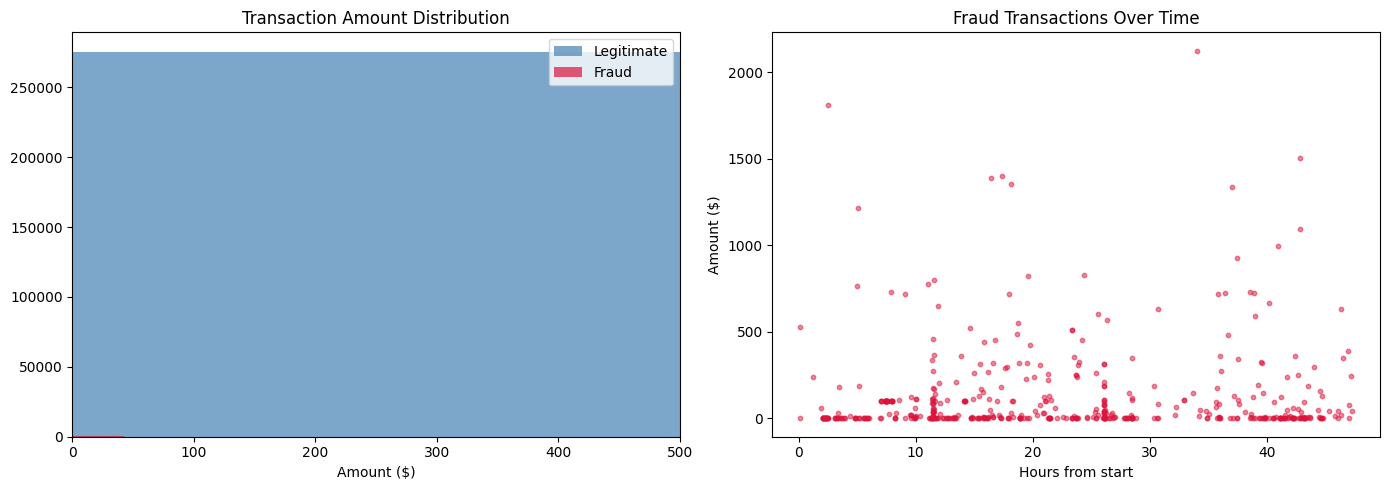

In [5]:
# Amount statistics — fraud vs legitimate
print("LEGITIMATE transactions:")
print(df[df['Class']==0]['Amount'].describe().round(2))
print(f"\nFRAUDULENT transactions:")
print(df[df['Class']==1]['Amount'].describe().round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Legitimate', color='steelblue')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='crimson')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Fraud over time
axes[1].scatter(df[df['Class']==1]['Time']/3600, df[df['Class']==1]['Amount'], alpha=0.5, color='crimson', s=10)
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Hours from start')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

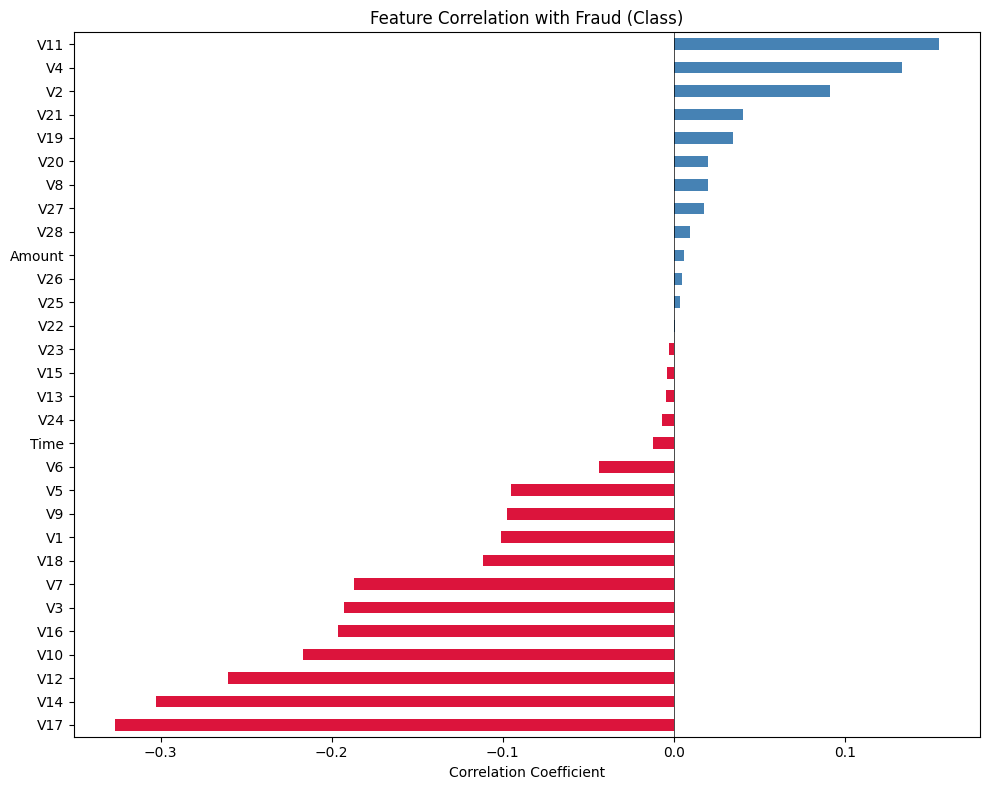

Top features POSITIVELY correlated with fraud (higher value = more likely fraud):
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549
Name: Class, dtype: float64

Top features NEGATIVELY correlated with fraud (lower value = more likely fraud):
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
Name: Class, dtype: float64


In [6]:
# Which features correlate most with fraud?
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['crimson' if x < 0 else 'steelblue' for x in correlations]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Feature Correlation with Fraud (Class)')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Top 5 most correlated (positive and negative)
print("Top features POSITIVELY correlated with fraud (higher value = more likely fraud):")
print(correlations.tail(5).round(4))
print("\nTop features NEGATIVELY correlated with fraud (lower value = more likely fraud):")
print(correlations.head(5).round(4))

In [7]:
# FEATURE ENGINEERING PIPELINE
# This is what separates a toy model from a production system

def engineer_features(df):
    """
    Transform raw transaction data into ML-ready features.
    In production at Mastercard, this would include cardholder history,
    merchant profiles, geographic data, etc. With this anonymized dataset,
    we engineer what we can from Amount and Time.
    """
    features = df.copy()
    
    # === TIME-BASED FEATURES ===
    # Convert seconds to hours — captures time-of-day patterns
    features['hour'] = (features['Time'] / 3600) % 24
    
    # Is it a night transaction? (midnight to 6 AM — higher fraud risk)
    features['is_night'] = ((features['hour'] >= 0) & (features['hour'] < 6)).astype(int)
    
    # === AMOUNT-BASED FEATURES ===
    # Log-transform amount — reduces impact of extreme values
    # A $10,000 transaction isn't 100x more suspicious than $100
    features['amount_log'] = np.log1p(features['Amount'])
    
    # Amount relative to global statistics
    features['amount_zscore'] = (features['Amount'] - features['Amount'].mean()) / features['Amount'].std()
    
    # Amount bins — categorical risk tiers
    features['amount_bin'] = pd.cut(features['Amount'], 
                                     bins=[0, 1, 10, 50, 200, 1000, float('inf')],
                                     labels=[0, 1, 2, 3, 4, 5]).astype(float)
    
    # Is it a round number? Fraudsters often use round amounts
    features['is_round_amount'] = (features['Amount'] % 10 == 0).astype(int)
    
    # === INTERACTION FEATURES ===
    # Combine the strongest correlated V-features with amount
    features['v14_x_v12'] = features['V14'] * features['V12']
    features['v17_x_amount'] = features['V17'] * features['amount_log']
    features['v14_x_amount'] = features['V14'] * features['amount_log']
    
    # Ratio of top fraud-correlated features
    features['v14_v11_ratio'] = features['V14'] / (features['V11'] + 1e-6)
    
    # === AGGREGATED RISK SCORE ===
    # Combine the top negatively-correlated features into a single risk signal
    features['fraud_risk_signal'] = -(features['V17'] + features['V14'] + features['V12'] + features['V10'])
    
    return features

# Run the pipeline
df_featured = engineer_features(df)

# Show what we created
new_features = [col for col in df_featured.columns if col not in df.columns]
print(f"Original features: {len(df.columns)}")
print(f"New engineered features: {len(new_features)}")
print(f"Total features: {len(df_featured.columns)}")
print(f"\nNew features created:")
for f in new_features:
    print(f"  {f}")

# Check correlation of new features with fraud
new_corr = df_featured[new_features + ['Class']].corr()['Class'].drop('Class').sort_values(ascending=False)
print(f"\nNew feature correlations with fraud:")
print(new_corr.round(4))

Original features: 31
New engineered features: 11
Total features: 42

New features created:
  hour
  is_night
  amount_log
  amount_zscore
  amount_bin
  is_round_amount
  v14_x_v12
  v17_x_amount
  v14_x_amount
  v14_v11_ratio
  fraud_risk_signal

New feature correlations with fraud:
v14_x_v12            0.5827
fraud_risk_signal    0.5440
is_night             0.0252
amount_zscore        0.0056
v14_v11_ratio        0.0026
is_round_amount      0.0013
amount_bin          -0.0070
amount_log          -0.0083
hour                -0.0171
v14_x_amount        -0.2335
v17_x_amount        -0.2934
Name: Class, dtype: float64


In [8]:
# PREPARE DATA FOR MODEL TRAINING
from sklearn.model_selection import train_test_split

# Define features and target
# Drop non-feature columns
drop_cols = ['Class', 'Time']  # Time is raw — we've extracted hour and is_night
feature_cols = [col for col in df_featured.columns if col not in drop_cols]

X = df_featured[feature_cols]
y = df_featured['Class']

# TIME-BASED SPLIT — not random!
# In production, you always train on past data and test on future data
# Random splitting would leak future information into training
split_index = int(len(df_featured) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"  Frauds: {y_train.sum():,.0f} ({y_train.mean()*100:.3f}%)")
print(f"\nTest set: {X_test.shape[0]:,} transactions")
print(f"  Frauds: {y_test.sum():,.0f} ({y_test.mean()*100:.3f}%)")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"\n--- WHY TIME-BASED SPLIT? ---")
print(f"Random split would let the model 'see' future transactions during training.")
print(f"In production, your model only ever sees past data. Time-based split simulates reality.")

Training set: 227,845 transactions
  Frauds: 417 (0.183%)

Test set: 56,962 transactions
  Frauds: 75 (0.132%)

Features: 40

--- WHY TIME-BASED SPLIT? ---
Random split would let the model 'see' future transactions during training.
In production, your model only ever sees past data. Time-based split simulates reality.


In [9]:
# Save the processed data
df_featured.to_csv('data/processed/creditcard_featured.csv', index=False)

# Save train/test splits
X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print(f"Saved processed data to data/processed/")
print(f"  creditcard_featured.csv: {len(df_featured):,} rows x {len(df_featured.columns)} cols")
print(f"  X_train.csv: {len(X_train):,} rows")
print(f"  X_test.csv: {len(X_test):,} rows")

Saved processed data to data/processed/
  creditcard_featured.csv: 284,807 rows x 42 cols
  X_train.csv: 227,845 rows
  X_test.csv: 56,962 rows


In [10]:
%%writefile pipeline/ingestion/feature_engineering.py
"""
Feature Engineering Pipeline for Fraud Detection
Enterprise MLOps Platform

This module transforms raw transaction data into ML-ready features.
In production, this same code runs in both:
  - Batch mode (for model training)
  - Real-time mode (for transaction-time scoring via feature store)

Keeping feature logic in one place prevents training-serving skew.
"""

import pandas as pd
import numpy as np

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform raw transaction data into ML-ready features.
    
    Args:
        df: Raw transaction DataFrame with columns: Time, V1-V28, Amount, Class
    
    Returns:
        DataFrame with original + engineered features
    """
    features = df.copy()
    
    # Time-based features
    features['hour'] = (features['Time'] / 3600) % 24
    features['is_night'] = ((features['hour'] >= 0) & (features['hour'] < 6)).astype(int)
    
    # Amount-based features
    features['amount_log'] = np.log1p(features['Amount'])
    features['amount_zscore'] = (features['Amount'] - features['Amount'].mean()) / features['Amount'].std()
    features['amount_bin'] = pd.cut(
        features['Amount'],
        bins=[0, 1, 10, 50, 200, 1000, float('inf')],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(float)
    features['is_round_amount'] = (features['Amount'] % 10 == 0).astype(int)
    
    # Interaction features
    features['v14_x_v12'] = features['V14'] * features['V12']
    features['v17_x_amount'] = features['V17'] * features['amount_log']
    features['v14_x_amount'] = features['V14'] * features['amount_log']
    features['v14_v11_ratio'] = features['V14'] / (features['V11'] + 1e-6)
    
    # Aggregated risk score
    features['fraud_risk_signal'] = -(features['V17'] + features['V14'] + features['V12'] + features['V10'])
    
    return features

def get_feature_columns(df: pd.DataFrame) -> list:
    """Return list of feature columns (excluding target and raw time)."""
    return [col for col in df.columns if col not in ['Class', 'Time']]

def prepare_train_test(df: pd.DataFrame, train_ratio: float = 0.8):
    """
    Time-based train/test split.
    
    Why time-based, not random?
    In production, models only see past data. Random splitting
    leaks future information into training and gives unrealistic metrics.
    """
    df_featured = engineer_features(df)
    feature_cols = get_feature_columns(df_featured)
    
    split_index = int(len(df_featured) * train_ratio)
    
    X_train = df_featured[feature_cols].iloc[:split_index]
    X_test = df_featured[feature_cols].iloc[split_index:]
    y_train = df_featured['Class'].iloc[:split_index]
    y_test = df_featured['Class'].iloc[split_index:]
    
    return X_train, X_test, y_train, y_test


if __name__ == "__main__":
    # Quick test
    df = pd.read_csv('data/raw/creditcard.csv')
    X_train, X_test, y_train, y_test = prepare_train_test(df)
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"Train fraud rate: {y_train.mean()*100:.3f}%")
    print(f"Test fraud rate: {y_test.mean()*100:.3f}%")

Writing pipeline/ingestion/feature_engineering.py
